✅ 載入: SparkBodyDaTa V.2 -  Sheet1 (1).tsv  (190 筆)
✅ 載入: 3242.tsv  (2810 筆)

查詢範圍：2026-03-24 台灣時間 10:30 ~ 12:00
         status      sessionId  台灣開始  台灣結束  筆數  KT均值  Spread均值
        ❌ 少於10筆 sess_ys157bttz 10:47 10:47   2 0.500     0.500
❌ 無Baseline_End sess_qw3oth54b 10:48 10:49  80 0.587     0.128
           ✅ 有效 sess_dzrg5cjnh 10:50 10:52  32 0.667     0.603
           ✅ 有效 sess_gdjowb7lg 10:52 10:54  43 0.548     0.413
           ✅ 有效 sess_g9qmb3sao 10:54 10:54  26 0.570     0.793
        ❌ 少於10筆 sess_ku27wkp27 10:54 10:55  11 0.529     0.521
        ❌ 少於10筆 sess_se2jix0r4 10:56 10:56   2 0.500     0.500
        ❌ 少於10筆 sess_583lintiq 10:56 10:56   4 0.500     0.500
           ✅ 有效 sess_pp60os06z 10:56 10:58  57 0.747     0.268
           ✅ 有效 sess_hommymj0s 10:58 10:59  41 0.611     0.533
        ❌ 少於10筆 sess_vdmb704jn 10:58 10:58  15 0.468     0.627
        ❌ 少於10筆 sess_y0g6o093p 10:59 11:00   8 0.508     0.282
           ✅ 有效 sess_ac72ltsox 11:00 11:02  76 0.702     0.897
      

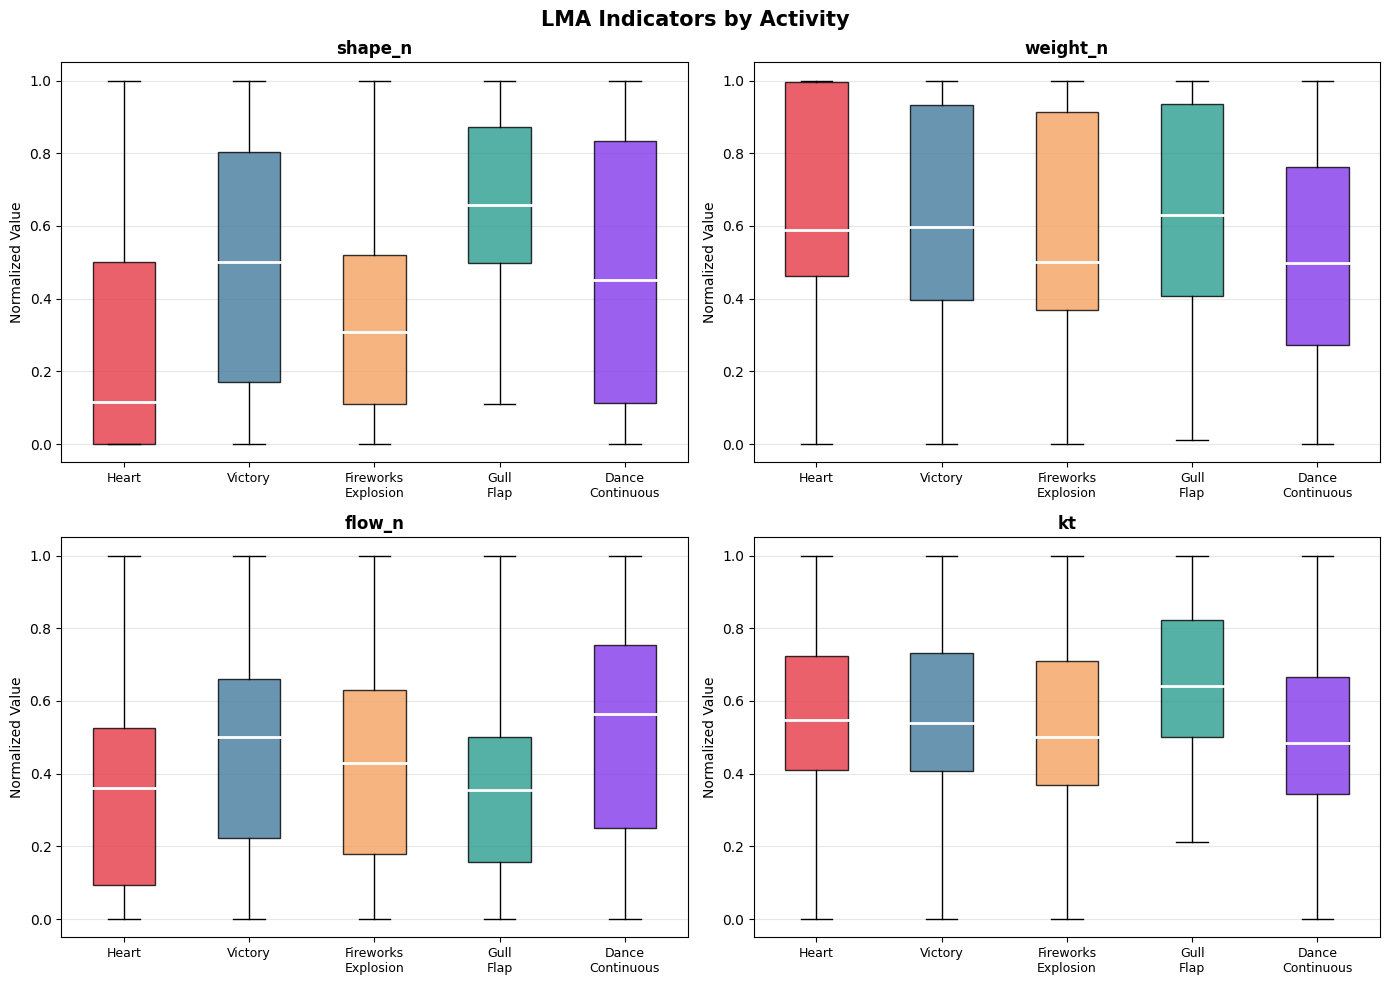

✅ fig1 saved


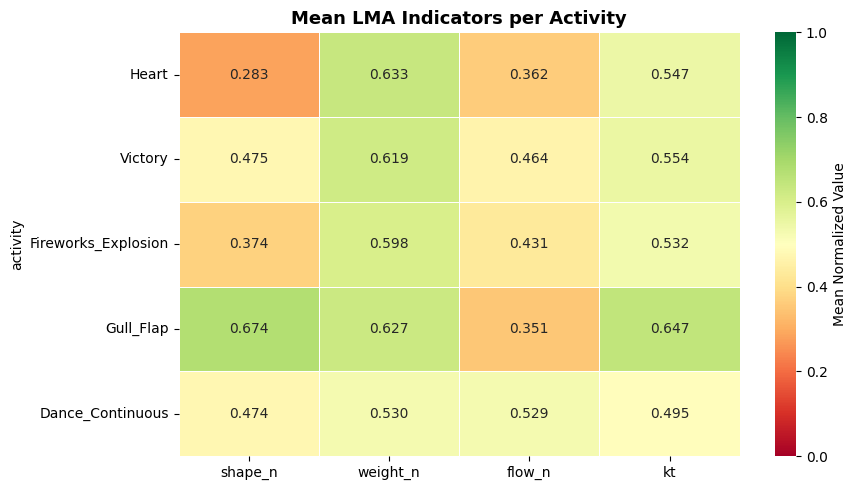

✅ fig2 saved


C:\Users\user\AppData\Local\Temp\ipykernel_20580\4228264418.py:190: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap("tab10", len(session_means))


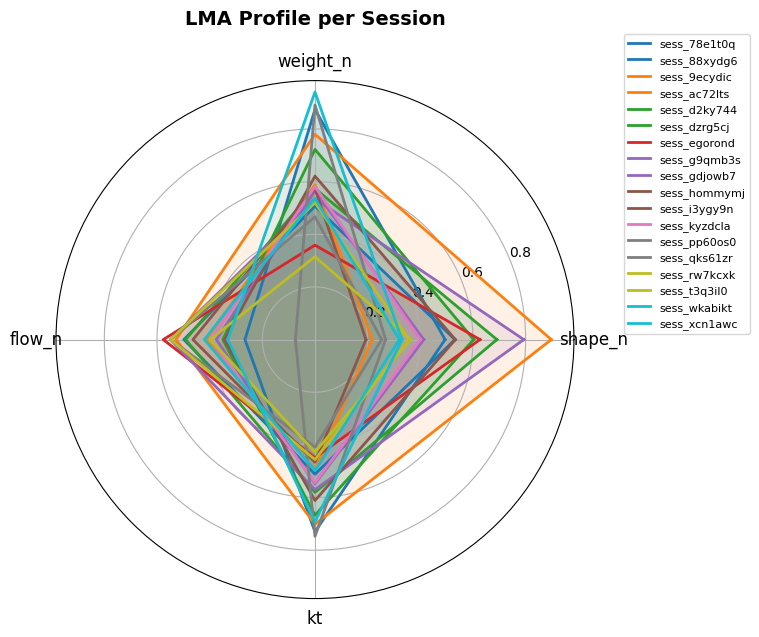

✅ fig3 saved


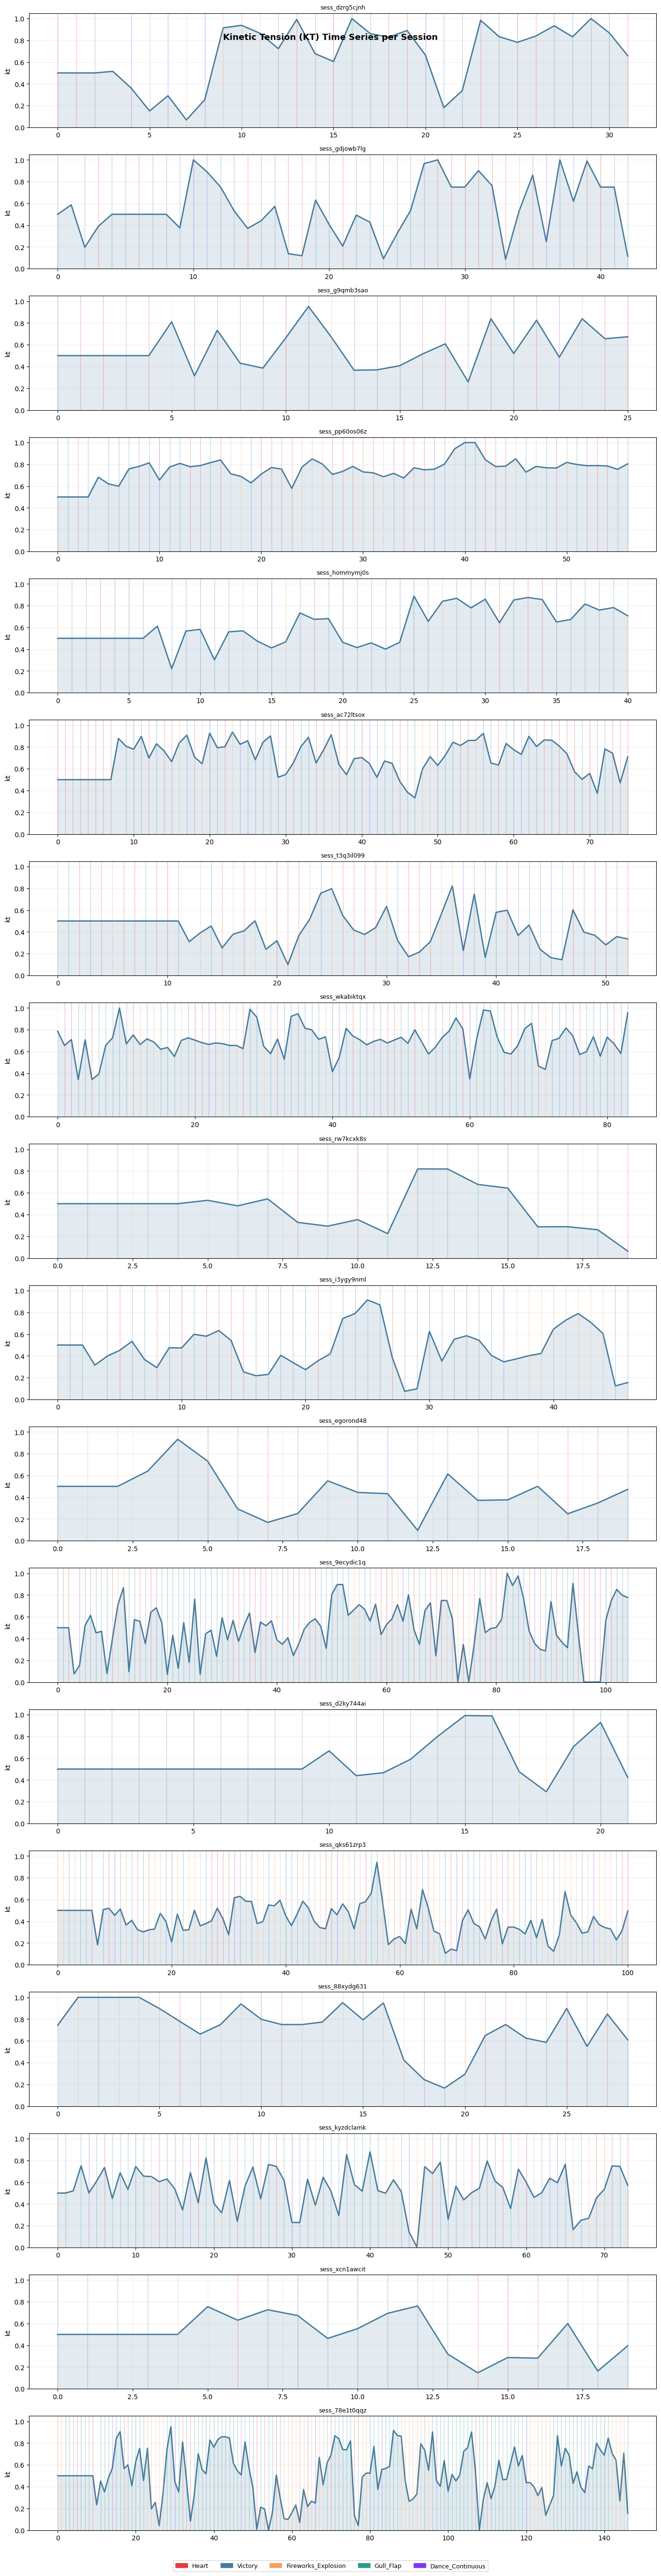

✅ fig4 saved

🎬 開始產出 MP4...
🎬 sess_dzrg5cjnh.mp4 done
🎬 sess_gdjowb7lg.mp4 done
🎬 sess_g9qmb3sao.mp4 done
🎬 sess_pp60os06z.mp4 done
🎬 sess_hommymj0s.mp4 done
🎬 sess_ac72ltsox.mp4 done
🎬 sess_t3q3il099.mp4 done
🎬 sess_wkabiktqx.mp4 done
🎬 sess_rw7kcxk8s.mp4 done
🎬 sess_i3ygy9nml.mp4 done
🎬 sess_egorond48.mp4 done
🎬 sess_9ecydic1q.mp4 done
🎬 sess_d2ky744ai.mp4 done
🎬 sess_qks61zrp3.mp4 done
🎬 sess_88xydg631.mp4 done
🎬 sess_kyzdclamk.mp4 done
🎬 sess_xcn1awcit.mp4 done
🎬 sess_78e1t0qqz.mp4 done

📄 論文 Methods 可直接使用的數字
A total of 1308 records were collected from 18 participants.
Sessions with fewer than 20 records or missing baseline calibration were excluded,
yielding 997 valid observations across 18 participants.

  shape_n: M=0.432, SD=0.355
  weight_n: M=0.614, SD=0.302
  flow_n: M=0.423, SD=0.292
  kt: M=0.556, SD=0.222

✅ 所有輸出存於: C:\Users\user\posefireworks\analysis_lab\plots


In [1]:
# =====================================
# SparkBody 完整分析 v2 - 單 Cell
# IEEE TAC Affective Intelligence & Art Design
# =====================================

import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.animation as animation
import seaborn as sns
from pathlib import Path

# =====================================================
# ⚙️ 設定區（只需改這裡）
# =====================================================

TSV_PATHS = [
    r"C:\Users\user\posefireworks\analysis_lab\raw_data\SparkBodyDaTa V.2 -  Sheet1 (1).tsv",
    r"C:\Users\user\posefireworks\analysis_lab\raw_data\3242.tsv",
]

FFMPEG_EXE = r"C:\Users\user\posefireworks\analysis_lab\ffmpeg.exe"
PLOTS_DIR  = Path("plots")
PLOTS_DIR.mkdir(exist_ok=True)

# --- 查詢時間範圍（台灣時間，設 None 代表不限）---
QUERY_DATE       = "2026-03-24"   # 日期
QUERY_TIME_START = "10:30"        # 台灣時間開始
QUERY_TIME_END   = "12:00"        # 台灣時間結束

# --- 篩選條件 ---
MIN_ROWS         = 20             # 最少筆數
SPREAD_ABNORMAL  = 0.15           # spread 均值低於此值標記異常（站太近）

# --- 圖表設定 ---
LMA_COLS   = ["shape_n", "weight_n", "flow_n", "kt"]
ACTIVITIES = ["Heart", "Victory", "Fireworks_Explosion", "Gull_Flap", "Dance_Continuous"]
COLORS     = ["#E63946", "#457B9D", "#F4A261", "#2A9D8F", "#8338EC"]
ACT_COLOR  = dict(zip(ACTIVITIES, COLORS))

# =====================================================
# 1️⃣ 讀取與合併所有 TSV
# =====================================================
dfs = []
for path in TSV_PATHS:
    try:
        with open(path, encoding="utf-8") as f:
            raw = f.read()
        lines = [l for l in raw.split("\n") if "\t" in l]
        df = pd.read_csv(
            io.StringIO("\n".join(lines)),
            sep="\t", header=None,
            names=["sessionId","userId","timestamp","mode","activity",
                   "shape_n","weight_n","flow_n","kt","baselineReady",
                   "lh_x","lh_y","rh_x","rh_y","ls_x","ls_y","rs_x","rs_y","note"]
        )
        dfs.append(df)
        print(f"✅ 載入: {Path(path).name}  ({len(df)} 筆)")
    except Exception as e:
        print(f"❌ 無法載入: {path}  ({e})")

df_all = pd.concat(dfs, ignore_index=True)

# 型別轉換
df_all["baselineReady"] = df_all["baselineReady"].astype(str).str.upper() == "TRUE"
df_all["timestamp"]     = pd.to_datetime(df_all["timestamp"], errors="coerce", utc=True)
for c in LMA_COLS:
    df_all[c] = pd.to_numeric(df_all[c], errors="coerce")
coord_cols = ["lh_x","lh_y","rh_x","rh_y","ls_x","ls_y","rs_x","rs_y"]
for c in coord_cols:
    df_all[c] = pd.to_numeric(df_all[c], errors="coerce")

# 基本排除
df_all = df_all[df_all["sessionId"] != "sess_test"]
df_all = df_all[df_all["userId"]    != "anonymous"]

# =====================================================
# 2️⃣ 時間範圍篩選 + Session 有效性判斷
# =====================================================
tw_start = pd.Timestamp(f"{QUERY_DATE} {QUERY_TIME_START}+08:00")
tw_end   = pd.Timestamp(f"{QUERY_DATE} {QUERY_TIME_END}+08:00")
df_range = df_all[(df_all["timestamp"] >= tw_start) & (df_all["timestamp"] <= tw_end)]

session_info = []
for sid in df_range["sessionId"].unique():
    sub          = df_range[df_range["sessionId"] == sid]
    n            = len(sub)
    has_baseline = (sub["activity"] == "Baseline_End").any()
    spread_mean  = sub["shape_n"].mean()
    kt_mean      = sub["kt"].mean()
    kt_sd        = sub["kt"].std()
    t_start_tw   = sub["timestamp"].min() + pd.Timedelta(hours=8)
    t_end_tw     = sub["timestamp"].max() + pd.Timedelta(hours=8)

    if n < MIN_ROWS:
        status = "❌ 少於10筆"
    elif not has_baseline:
        status = "❌ 無Baseline_End"
    elif pd.notna(spread_mean) and spread_mean < SPREAD_ABNORMAL:
        status = "⚠️ 疑似站太近"
    else:
        status = "✅ 有效"

    session_info.append({
        "status"    : status,
        "sessionId" : sid,
        "台灣開始"  : str(t_start_tw)[11:16],
        "台灣結束"  : str(t_end_tw)[11:16],
        "筆數"      : n,
        "KT均值"    : round(kt_mean, 3) if pd.notna(kt_mean) else "-",
        "KT標準差"  : round(kt_sd, 3)   if pd.notna(kt_sd)   else "-",
        "Spread均值": round(spread_mean, 3) if pd.notna(spread_mean) else "-",
    })

df_sessions = pd.DataFrame(session_info).sort_values("台灣開始")
valid_ids   = df_sessions[df_sessions["status"] == "✅ 有效"]["sessionId"].tolist()

print(f"\n查詢範圍：{QUERY_DATE} 台灣時間 {QUERY_TIME_START} ~ {QUERY_TIME_END}")
print(df_sessions[["status","sessionId","台灣開始","台灣結束","筆數","KT均值","Spread均值"]].to_string(index=False))
print(f"\n✅ 有效：{len(valid_ids)} 個　⚠️ 異常：{df_sessions['status'].str.startswith('⚠️').sum()} 個　❌ 排除：{df_sessions['status'].str.startswith('❌').sum()} 個")

# =====================================================
# 3️⃣ 後續分析只用有效 session
# =====================================================
df = df_range[df_range["sessionId"].isin(valid_ids)].dropna(subset=coord_cols).copy().reset_index(drop=True)
df_act = df[df["activity"].isin(ACTIVITIES)].copy()

n_total    = len(df_range)
n_valid    = len(df)
n_sessions = df["sessionId"].nunique()

print(f"\n分析用筆數：{n_valid}　Session：{n_sessions} 人")

# =====================================================
# 4️⃣ 論文用統計 mean ± SD
# =====================================================
print("\n=== Overall LMA mean ± SD ===")
for col in LMA_COLS:
    print(f"  {col:<12}: {df[col].mean():.3f} ± {df[col].std():.3f}")

print("\n=== Per-activity KT mean ± SD ===")
for act in ACTIVITIES:
    sub = df_act[df_act["activity"] == act]["kt"]
    if len(sub) > 0:
        print(f"  {act:<25}: {sub.mean():.3f} ± {sub.std():.3f}  (n={len(sub)})")

print("\n=== Per-session LMA mean ===")
print(df.groupby("sessionId")[LMA_COLS].mean().round(3).to_string())

# =====================================================
# 5️⃣ 圖1：盒鬚圖 LMA × Activity
# =====================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("LMA Indicators by Activity", fontsize=15, fontweight="bold")
for ax, col in zip(axes.flat, LMA_COLS):
    data = [df_act[df_act["activity"] == a][col].dropna().values for a in ACTIVITIES]
    bp = ax.boxplot(data, patch_artist=True, medianprops=dict(color="white", linewidth=2))
    for patch, color in zip(bp["boxes"], COLORS):
        patch.set_facecolor(color); patch.set_alpha(0.8)
    ax.set_xticks(range(1, len(ACTIVITIES)+1))
    ax.set_xticklabels([a.replace("_", "\n") for a in ACTIVITIES], fontsize=9)
    ax.set_title(col, fontsize=12, fontweight="bold")
    ax.set_ylabel("Normalized Value"); ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "fig1_lma_boxplot.png", dpi=300, bbox_inches="tight")
plt.show(); print("✅ fig1 saved")

# =====================================================
# 6️⃣ 圖2：熱力圖 Activity × LMA
# =====================================================
heatmap_data = df_act.groupby("activity")[LMA_COLS].mean().reindex(ACTIVITIES)
fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(heatmap_data, annot=True, fmt=".3f", cmap="RdYlGn",
            vmin=0, vmax=1, linewidths=0.5, ax=ax,
            cbar_kws={"label": "Mean Normalized Value"})
ax.set_title("Mean LMA Indicators per Activity", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "fig2_lma_heatmap.png", dpi=300, bbox_inches="tight")
plt.show(); print("✅ fig2 saved")

# =====================================================
# 7️⃣ 圖3：雷達圖 Session × LMA
# =====================================================
session_means = df.groupby("sessionId")[LMA_COLS].mean()
N      = len(LMA_COLS)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist() + [0]
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
cmap = plt.cm.get_cmap("tab10", len(session_means))
for i, (sid, row) in enumerate(session_means.iterrows()):
    values = row[LMA_COLS].tolist() + [row[LMA_COLS[0]]]
    ax.plot(angles, values, linewidth=2, color=cmap(i), label=sid[:12])
    ax.fill(angles, values, alpha=0.1, color=cmap(i))
ax.set_xticks(angles[:-1]); ax.set_xticklabels(LMA_COLS, fontsize=12)
ax.set_title("LMA Profile per Session", fontsize=14, fontweight="bold", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.1), fontsize=8)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "fig3_lma_radar.png", dpi=300, bbox_inches="tight")
plt.show(); print("✅ fig3 saved")

# =====================================================
# 8️⃣ 圖4：KT 時序圖 per session
# =====================================================
sessions = df["sessionId"].unique()
fig, axes = plt.subplots(len(sessions), 1, figsize=(14, 3*len(sessions)))
if len(sessions) == 1: axes = [axes]
for ax, sid in zip(axes, sessions):
    sdf = df[df["sessionId"] == sid].reset_index(drop=True)
    ax.plot(sdf.index, sdf["kt"], color="#457B9D", linewidth=2)
    ax.fill_between(sdf.index, sdf["kt"], alpha=0.15, color="#457B9D")
    for idx, row in sdf.iterrows():
        if row["activity"] in ACT_COLOR:
            ax.axvline(idx, color=ACT_COLOR[row["activity"]], alpha=0.3, linewidth=1)
    ax.set_title(f"{sid}", fontsize=9); ax.set_ylim(0, 1.05)
    ax.set_ylabel("kt"); ax.grid(alpha=0.2)
patches = [mpatches.Patch(color=c, label=a) for a, c in ACT_COLOR.items()]
fig.legend(handles=patches, loc="lower center", ncol=5, fontsize=9, bbox_to_anchor=(0.5, -0.01))
fig.suptitle("Kinetic Tension (KT) Time Series per Session", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "fig4_kt_timeseries.png", dpi=300, bbox_inches="tight")
plt.show(); print("✅ fig4 saved")

# =====================================================
# 9️⃣ 動畫 MP4
# =====================================================
def export_session_mp4(sid):
    vsdf = df[df["sessionId"] == sid].copy().reset_index(drop=True)
    if vsdf.empty:
        print(f"⚠️ 無資料: {sid}"); return
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.set_xlim(1, 0); ax.set_ylim(1, 0)
    ax.set_title(f"Session: {sid}", fontsize=11)
    line_l, = ax.plot([], [], "g-o", lw=4, label="Left Arm")
    line_r, = ax.plot([], [], "r-o", lw=4, label="Right Arm")
    line_s, = ax.plot([], [], "b-",  lw=4, alpha=0.5, label="Shoulders")
    act_text = ax.text(0.05, 0.05, "", transform=ax.transAxes, fontsize=9, color="gray")
    ax.legend(loc="upper right", fontsize=8)
    def update(frame):
        row = vsdf.iloc[frame]
        line_l.set_data([row.ls_x, row.lh_x], [row.ls_y, row.lh_y])
        line_r.set_data([row.rs_x, row.rh_x], [row.rs_y, row.rh_y])
        line_s.set_data([row.ls_x, row.rs_x], [row.ls_y, row.rs_y])
        act_text.set_text(f"{row.activity}  kt={row.kt:.2f}")
        return line_l, line_r, line_s, act_text
    ani = animation.FuncAnimation(fig, update, frames=len(vsdf), interval=200, blit=True)
    try:
        writer = animation.FFMpegWriter(fps=3)
        writer.executable = FFMPEG_EXE
        ani.save(PLOTS_DIR / f"{sid}.mp4", writer=writer)
        print(f"🎬 {sid}.mp4 done")
    except Exception as e:
        print(f"❌ {sid} 失敗: {e}")
    plt.close(fig)

print("\n🎬 開始產出 MP4...")
for sid in df["sessionId"].unique():
    export_session_mp4(sid)

# =====================================================
# ✅ 論文用數字摘要
# =====================================================
print("\n" + "="*55)
print("📄 論文 Methods 可直接使用的數字")
print("="*55)
print(f"A total of {n_total} records were collected from {n_sessions} participants.")
print(f"Sessions with fewer than {MIN_ROWS} records or missing baseline calibration were excluded,")
print(f"yielding {n_valid} valid observations across {n_sessions} participants.")
print()
for col in LMA_COLS:
    print(f"  {col}: M={df[col].mean():.3f}, SD={df[col].std():.3f}")
print(f"\n✅ 所有輸出存於: {PLOTS_DIR.resolve()}")
